--- Top 10 Longest Tracks ---
                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  


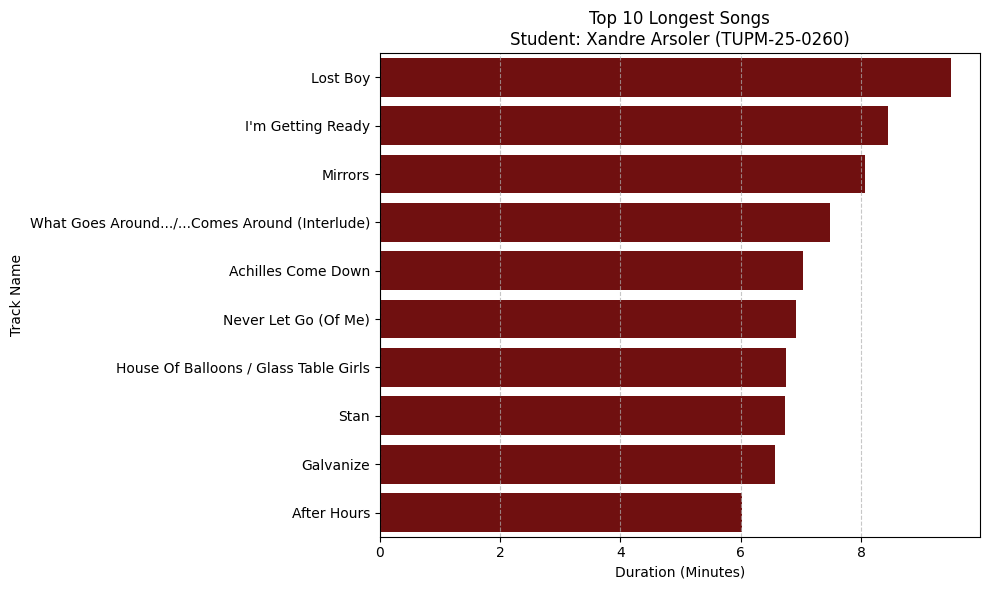

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"
color_bar = "maroon"  

longest_tracks = df.sort_values(by='duration_min', ascending=False).head(10)

print("--- Top 10 Longest Tracks ---")
print(longest_tracks[['track_name', 'artist', 'duration_min']])

plt.figure(figsize=(10, 6))
sns.barplot(x='duration_min', y='track_name', data=longest_tracks, color=color_bar)

plt.title(f"Top 10 Longest Songs\nStudent: {student_name} ({student_id})")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Track Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


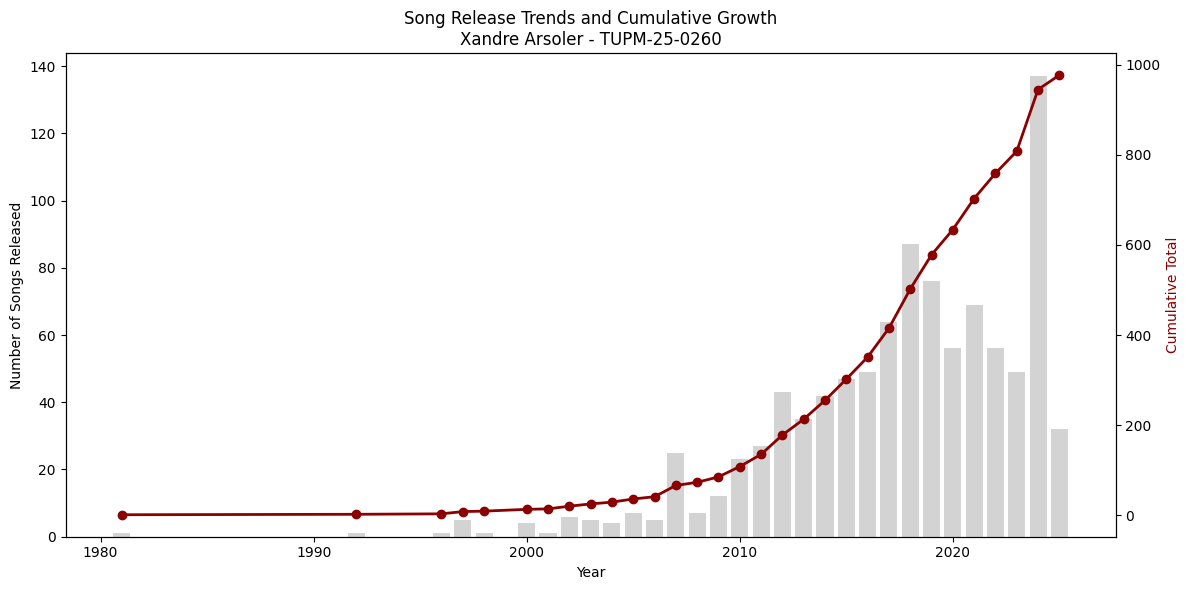

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify_top_1000_tracks.csv')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"
color_bar = "lightgrey"
color_line = "darkred"

yearly_counts = df.groupby('year').size().reset_index(name='song_count')
yearly_counts['cumulative_count'] = yearly_counts['song_count'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(yearly_counts['year'], yearly_counts['song_count'], color=color_bar, label='Yearly Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Songs Released', color='black')

ax2 = ax1.twinx()
ax2.plot(yearly_counts['year'], yearly_counts['cumulative_count'], 
         color=color_line, marker='o', linewidth=2, label='Cumulative Growth')
ax2.set_ylabel('Cumulative Total', color=color_line)

plt.title(f"Song Release Trends and Cumulative Growth\n{student_name} - {student_id}")

fig.tight_layout()
plt.show()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

df = pd.read_csv('spotify_top_1000_tracks.csv')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year', 'duration_min', 'popularity'])
df['year'] = df['year'].astype(int)

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"
cmap_color = "YlOrRd"  

fig, ax = plt.subplots(figsize=(10, 7))

def update(frame_year):
    ax.clear()
    yearly_data = df[df['year'] == frame_year]
    hb = ax.hexbin(yearly_data['duration_min'], yearly_data['popularity'], 
                   gridsize=20, cmap=cmap_color, mincnt=1)
    ax.set_title(f"Density Map: Duration vs Popularity ({frame_year})\nStudent: {student_name} ({student_id})")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity Score")
    ax.set_xlim(df['duration_min'].min(), df['duration_min'].max())
    ax.set_ylim(df['popularity'].min(), df['popularity'].max())

unique_years = sorted(df['year'].unique())[-20:] 

ani = animation.FuncAnimation(fig, update, frames=unique_years, interval=800)

plt.close() 
HTML(ani.to_jshtml()) 
